<a href="https://colab.research.google.com/github/sujitx-vs/PGCP-AI_PML/blob/main/Day13_PML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Apyori

In [ ]:
!pip install apyori

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
dataset = pd.read_csv('/content/Market_Basket.csv',header = None)

In [ ]:
dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dataset.tail()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
7496,butter,light mayo,fresh bread,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7497,burgers,frozen vegetables,eggs,french fries,magazines,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7498,chicken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7499,escalope,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7500,eggs,frozen smoothie,yogurt cake,low fat yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dataset.shape

(7501, 20)

In [ ]:
transactions = []
for i in range(0,7501):
  transactions.append([str(dataset.values[i,j])for j in range(0,20)])

In [ ]:
transactions

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers',
  'meatballs',
  'eggs',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan'],
 ['chutney',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan'],
 ['turkey',
  'avocado',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan'],
 ['mineral water',
  'milk',
  'energy bar',
  'whole wheat rice',
  'green tea',
  'nan',
  'nan',
  'nan',
 

In [ ]:
# apply apriori algorithm

from apyori import apriori
rules = apriori(transactions = transactions,min_support =0.003,
               min_confidence = 0.2, min_lift =3 ,
               min_length =2, max_length = 2)

In [ ]:
results = list(rules)

In [ ]:
print(results)

[RelationRecord(items=frozenset({'light cream', 'chicken'}), support=0.004532728969470737, ordered_statistics=[OrderedStatistic(items_base=frozenset({'light cream'}), items_add=frozenset({'chicken'}), confidence=0.29059829059829057, lift=4.84395061728395)]), RelationRecord(items=frozenset({'mushroom cream sauce', 'escalope'}), support=0.005732568990801226, ordered_statistics=[OrderedStatistic(items_base=frozenset({'mushroom cream sauce'}), items_add=frozenset({'escalope'}), confidence=0.3006993006993007, lift=3.790832696715049)]), RelationRecord(items=frozenset({'escalope', 'pasta'}), support=0.005865884548726837, ordered_statistics=[OrderedStatistic(items_base=frozenset({'pasta'}), items_add=frozenset({'escalope'}), confidence=0.3728813559322034, lift=4.700811850163794)]), RelationRecord(items=frozenset({'honey', 'fromage blanc'}), support=0.003332888948140248, ordered_statistics=[OrderedStatistic(items_base=frozenset({'fromage blanc'}), items_add=frozenset({'honey'}), confidence=0.24

In [ ]:
resultsindf = pd.DataFrame(results)

In [ ]:
resultsindf

,items,support,ordered_statistics
0,"(light cream, chicken)",0.004533,"[((light cream), (chicken), 0.2905982905982905..."
1,"(mushroom cream sauce, escalope)",0.005733,"[((mushroom cream sauce), (escalope), 0.300699..."
2,"(escalope, pasta)",0.005866,"[((pasta), (escalope), 0.3728813559322034, 4.7..."
3,"(honey, fromage blanc)",0.003333,"[((fromage blanc), (honey), 0.2450980392156863..."
4,"(ground beef, herb & pepper)",0.015998,"[((herb & pepper), (ground beef), 0.3234501347..."
5,"(ground beef, tomato sauce)",0.005333,"[((tomato sauce), (ground beef), 0.37735849056..."
6,"(olive oil, light cream)",0.003200,"[((light cream), (olive oil), 0.20512820512820..."
7,"(olive oil, whole wheat pasta)",0.007999,"[((whole wheat pasta), (olive oil), 0.27149321..."
8,"(shrimp, pasta)",0.005066,"[((pasta), (shrimp), 0.3220338983050847, 4.506..."


In [ ]:
def inspect(results):
  lhs = [tuple(result[2][0][0])[0] for result in results]
  rhs = [tuple(result[2][0][1])[0] for result in results]

  support = [result[1] for result in results]
  confidence = [result[2][0][2] for result in results]
  lifts = [result[2][0][3] for result in results]
  return list(zip(lhs,rhs,support,confidence,lifts))

  resultdf = pd.pd.DataFrame(inspect(results),columns = ['Left Hand Side','Right Hand Side','Support','Confidence','Lift'])
  # resultdf

In [ ]:
df = pd.DataFrame(inspect(results),columns = ['Left Hand Side','Right Hand Side','Support','Confidence','Lift'])

In [ ]:
df

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
0,light cream,chicken,0.004533,0.290598,4.843951
1,mushroom cream sauce,escalope,0.005733,0.300699,3.790833
2,pasta,escalope,0.005866,0.372881,4.700812
3,fromage blanc,honey,0.003333,0.245098,5.164271
4,herb & pepper,ground beef,0.015998,0.323450,3.291994
5,tomato sauce,ground beef,0.005333,0.377358,3.840659
6,light cream,olive oil,0.003200,0.205128,3.114710
7,whole wheat pasta,olive oil,0.007999,0.271493,4.122410
8,pasta,shrimp,0.005066,0.322034,4.506672


# Temperature Analysis

In [ ]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
temperature = pd.read_csv('/content/Temperature.csv')

In [ ]:
temperature

,Date,Temp
0,01-01-1981,20.7
1,02-01-1981,17.9
2,03-01-1981,18.8
3,04-01-1981,14.6
4,05-01-1981,15.8
...,...,...
3645,27-12-1990,14.0
3646,28-12-1990,13.6
3647,29-12-1990,13.5
3648,30-12-1990,15.7


In [ ]:
temperature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   object 
 1   Temp    3650 non-null   float64
dtypes: float64(1), object(1)
memory usage: 57.2+ KB


In [ ]:
temperature['Date'] = pd.to_datetime(temperature['Date'], format='%d-%m-%Y')

In [ ]:
temperature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3650 non-null   datetime64[ns]
 1   Temp    3650 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 57.2 KB


In [ ]:
temperature.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [ ]:
temperature = temperature.sort_values(by='Date')

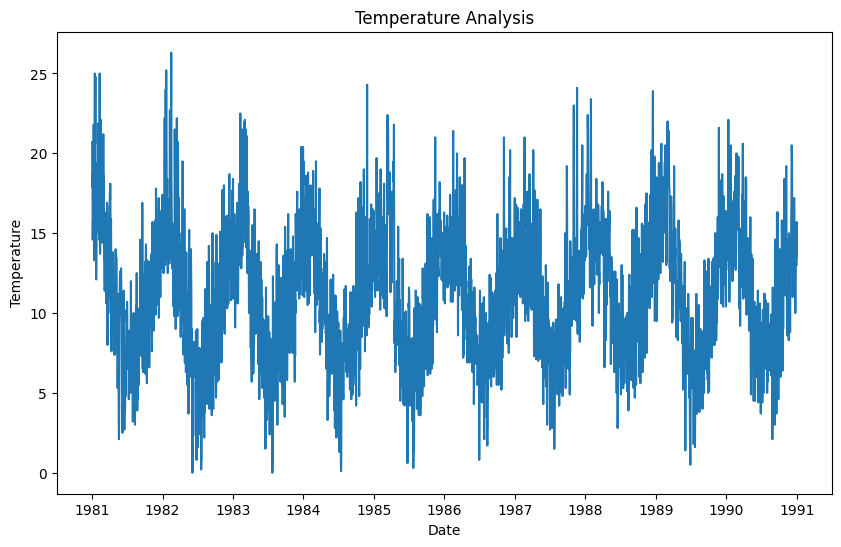

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(temperature['Date'],temperature['Temp'])
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Temperature Analysis')
plt.show()

#Time Series Analysis

- Used to analyse data points collected or recoreded at succsesive point of time.
- > Types of Time Series
    - Univariate - One variable
    - Bivariate - Two variables/parameters
    - Multivariate - Multiple parameters
- > Components of Time Series
    - Trend - Long term upward or downward movement in the data.
    - Seasonality - Regular, Repeating pattern at fixed intervel.
    - Cyclic Variation - Fluctuations occuring over longer duration.
    - Irregular Component - Unpredictable variation caused by random factors.
- > Common Methods
    - Moving Average
    - Exponential smoothing
    - ARIMA Model

- > Challenges
    - Data Quality
    - Overfitting
    - Stationary

In [ ]:
temperature['month'] = temperature['Date'].dt.month
temperature['year'] = temperature['Date'].dt.year

In [ ]:
temperature.head()

,Date,Temp,month,year
0,1981-01-01,20.7,1,1981
1,1981-01-02,17.9,1,1981
2,1981-01-03,18.8,1,1981
3,1981-01-04,14.6,1,1981
4,1981-01-05,15.8,1,1981
...,...,...,...,...
3645,1990-12-27,14.0,12,1990
3646,1990-12-28,13.6,12,1990
3647,1990-12-29,13.5,12,1990
3648,1990-12-30,15.7,12,1990


In [ ]:
temperature['MA12'] = temperature['Temp'].rolling(window=12).mean() # Moving Average.

In [ ]:
temperature.head()

,Date,Temp,month,year,MA12
0,1981-01-01,20.7,1,1981,NaN
1,1981-01-02,17.9,1,1981,NaN
2,1981-01-03,18.8,1,1981,NaN
3,1981-01-04,14.6,1,1981,NaN
4,1981-01-05,15.8,1,1981,NaN


In [ ]:
temperature.shape

(3650, 5)

In [ ]:
series = np.arange(1,3651)

In [ ]:
temp_data["Series"]= series

/tmp/ipykernel_1341/2598719170.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_data["Series"]= series


In [ ]:
temp_data = temperature[['year','Temp','month']]

In [ ]:
temp_data = temp_data[['Series','year','month','Temp']]

In [ ]:
temp_data

,Series,year,month,Temp
0,1,1981,1,20.7
1,2,1981,1,17.9
2,3,1981,1,18.8
3,4,1981,1,14.6
4,5,1981,1,15.8
...,...,...,...,...
3645,3646,1990,12,14.0
3646,3647,1990,12,13.6
3647,3648,1990,12,13.5
3648,3649,1990,12,15.7


In [ ]:
X = temp_data.drop('Temp',axis =1)

In [ ]:
Y = temp_data['Temp']

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [ ]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train,Y_train)


LinearRegression()

In [ ]:
y_pred = regressor.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error
print("MSE :",mean_squared_error(Y_test,y_pred))
print("R2 Score :",r2_score(Y_test,y_pred))

MSE : 17.04253410031931
R2 Score : 0.07380580127051206


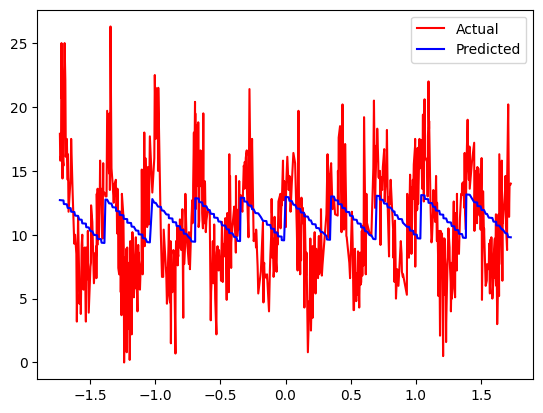

In [ ]:
sorted_index = np.argsort(X_test[:,0])
plt.plot(X_test[sorted_index,0],Y_test.iloc[sorted_index],color='red',label="Actual")
plt.plot(X_test[sorted_index,0],y_pred[sorted_index],color='blue',label="Predicted")
plt.legend()
plt.show()

# Temp2 Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score,mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima_model import ARIMA

In [ ]:
df = pd.read_csv('/content/Temp2.csv')

In [ ]:
df


,Month,Sales
0,1-01,266.0
1,1-02,145.9
2,1-03,183.1
3,1-04,119.3
4,1-05,180.3
5,1-06,168.5
6,1-07,231.8
7,1-08,224.5
8,1-09,192.8
9,1-10,122.9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Month   36 non-null     object 
 1   Sales   36 non-null     float64
dtypes: float64(1), object(1)
memory usage: 708.0+ bytes


In [ ]:
df['Month']= pd.to_datetime('190'+df['Month'],format = "%Y-%m")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Month   36 non-null     datetime64[ns]
 1   Sales   36 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 708.0 bytes


In [ ]:
df.set_index("Month",inplace=True)

In [ ]:
df.columns =['Sales']

In [ ]:
df.head()

,Sales
Month,
1901-01-01,266.0
1901-02-01,145.9
1901-03-01,183.1
1901-04-01,119.3
1901-05-01,180.3


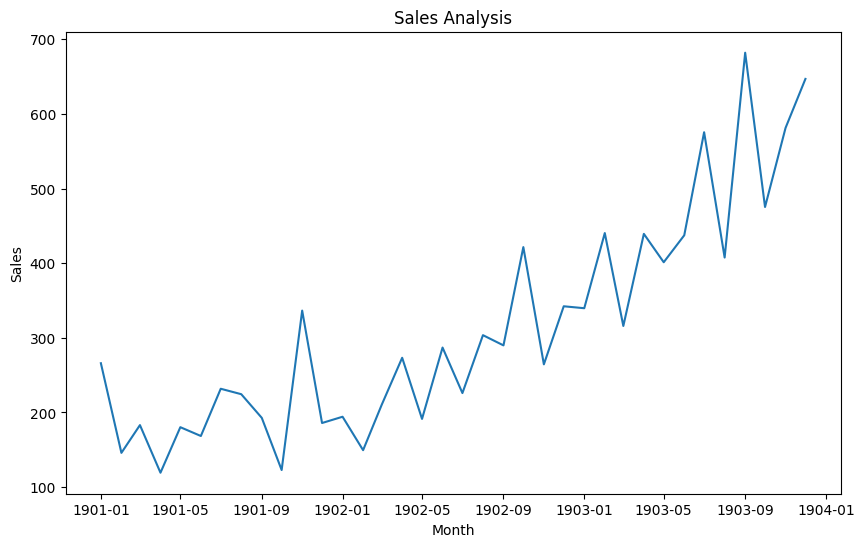

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(df['Sales'])
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Sales Analysis')
plt.show()

In [ ]:
def adf_test(series):
  result = adfuller(series)
  # ADF Statitics
  print(result[0])
  #P - Value
  print(result[1])
  #Critical Values
  # print(result[4])

  if result[1]<=0.05:
    print("Stationary")
  else:
    print("Not stationary")

adf_test(df['Sales'])

3.060142083641181
1.0
Not stationary


In [ ]:
# Make Stationary
df['Sales_diff'] = df['Sales'].diff()


In [ ]:
df.dropna(inplace=True)

In [ ]:
adf_test(df['Sales_diff'])

-7.249074055553854
1.7998574141687034e-10
Stationary


In [ ]:
# train test split. for time series
X = df['Sales'].values
train_size = int(len(X)*0.7)
train,test = X[:train_size],X[train_size:]

In [ ]:
train

array([145.9, 183.1, 119.3, 180.3, 168.5, 231.8, 224.5, 192.8, 122.9,
       336.5, 185.9, 194.3, 149.5, 210.1, 273.3, 191.4, 287. , 226. ,
       303.6, 289.9, 421.6, 264.5, 342.3, 339.7])

In [ ]:
# arima model
from statsmodels.tsa.arima.model import ARIMA

history = list(train)
predictions = []
for t in range(len(test)):
  model = ARIMA(history,order=(1,1,2))
  model_fit = model.fit()
  y_pred = model_fit.forecast()[0]
  predictions.append(y_pred)
  obs=test[t]
  history.append(obs)

  print(f'Prediction= {y_pred},Actual = {test[t]:2f}')

Prediction= 337.65149145038697,Actual = 440.400000
Prediction= 346.4992990300457,Actual = 315.900000
Prediction= 389.3627184038887,Actual = 439.300000
Prediction= 343.03395955987634,Actual = 401.300000
Prediction= 422.70821256569656,Actual = 437.400000
Prediction= 390.4922880322044,Actual = 575.500000
Prediction= 466.064431618551,Actual = 407.600000
Prediction= 542.7760197503173,Actual = 682.000000
Prediction= 517.2482315978104,Actual = 475.300000
Prediction= 626.2019142048235,Actual = 581.300000
Prediction= 620.2429194739422,Actual = 646.900000


In [ ]:
mse = mean_squared_error(test,predictions)
r2 = r2_score(test,predictions)
print("MSE :",mse)
print("R2 Score :",r2)

MSE : 7192.16192675554
R2 Score : 0.3918730254602817


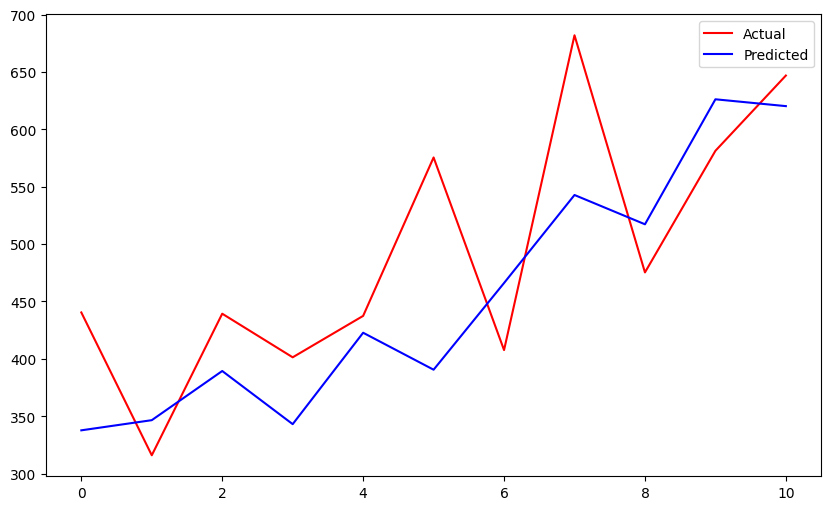

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(test,label="Actual",color="red")
plt.plot(predictions,label="Predicted",color="blue")
plt.legend()
plt.show()

# Temp1.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.metrics import r2_score,mean_squared_error
from statsmodels.tsa.stattools import
from statsmodels.tsa.arima_model import